# Setup

In [29]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import ParameterGrid

In [30]:
# Set the index when we import the data
df = pd.read_csv("Daily_Bike_Sharing_training.csv")
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701 entries, 0 to 700
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     701 non-null    int64  
 1   dteday      701 non-null    object 
 2   season      701 non-null    int64  
 3   yr          701 non-null    int64  
 4   mnth        701 non-null    int64  
 5   holiday     701 non-null    int64  
 6   weekday     701 non-null    int64  
 7   workingday  701 non-null    int64  
 8   weathersit  701 non-null    int64  
 9   temp        701 non-null    float64
 10  atemp       701 non-null    float64
 11  hum         701 non-null    float64
 12  windspeed   701 non-null    float64
 13  casual      701 non-null    int64  
 14  registered  701 non-null    int64  
 15  cnt         701 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 87.8+ KB


In [32]:
df = df.rename(columns={"dteday": "ds", "cnt": "y"})
df["ds"] = pd.to_datetime(df["ds"], format="%m/%d/%Y")
df.head()

,instant,ds,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,y
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [33]:
weather_sit = pd.get_dummies(df["weathersit"], drop_first=True, prefix="weathersit")
df = pd.concat([df, weather_sit], axis=1)
df.drop(columns=['instant', 'season', 'yr', 'mnth', 'weekday', "weathersit", 'casual', 'registered'], inplace=True)
df.head()

,ds,holiday,workingday,temp,atemp,hum,windspeed,y,weathersit_2,weathersit_3
0,2011-01-01,0,0,0.344167,0.363625,0.805833,0.160446,985,True,False
1,2011-01-02,0,0,0.363478,0.353739,0.696087,0.248539,801,True,False
2,2011-01-03,0,1,0.196364,0.189405,0.437273,0.248309,1349,False,False
3,2011-01-04,0,1,0.200000,0.212122,0.590435,0.160296,1562,False,False
4,2011-01-05,0,1,0.226957,0.229270,0.436957,0.186900,1600,False,False


In [34]:
df_temp = df.copy()
df_temp.set_index("ds", inplace=True)

In [37]:

df_temp.index.freq = "D"
df_temp.index

DatetimeIndex(['2011-01-01', '2011-01-02', '2011-01-03', '2011-01-04',
               '2011-01-05', '2011-01-06', '2011-01-07', '2011-01-08',
               '2011-01-09', '2011-01-10',
               ...
               '2012-11-22', '2012-11-23', '2012-11-24', '2012-11-25',
               '2012-11-26', '2012-11-27', '2012-11-28', '2012-11-29',
               '2012-11-30', '2012-12-01'],
              dtype='datetime64[ns]', name='ds', length=701, freq='D')

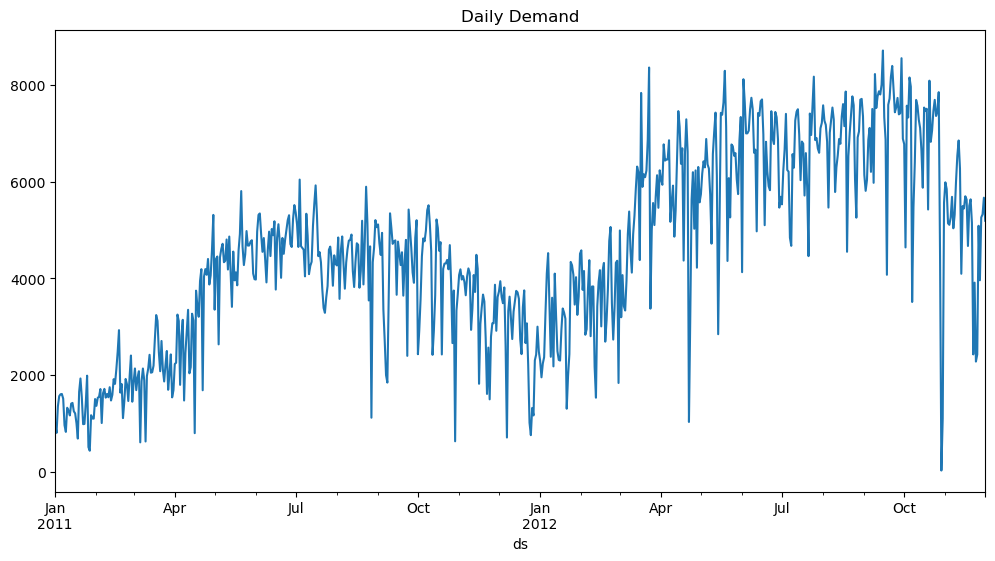

In [38]:
# Daily Closing Price Plot
df_temp["y"].plot(title= 'Daily Demand', figsize=(12, 6))
plt.show()

# Seasonality

/tmp/ipykernel_2984/4200696806.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_plot(df_temp['y'].resample('M').mean(), ylabel='Demand')


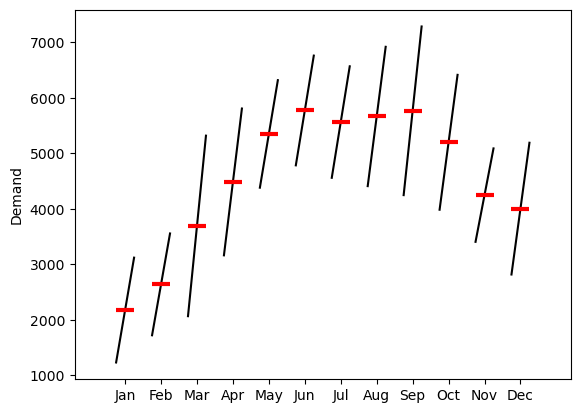

In [40]:
# Plot the month_plot
month_plot(df_temp['y'].resample('M').mean(), ylabel='Demand')
plt.show()

In [ ]:
# Plot the quarter_plot
quarter_plot(df['y'])
plt.show()

# (Partial) Auto-Correlation

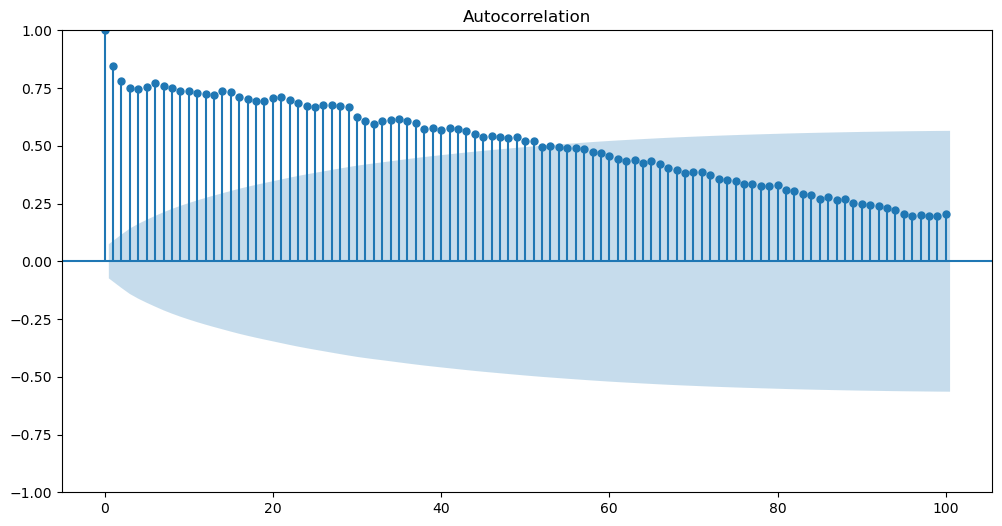

In [41]:
# Plot the ACF of the
fig, ax = plt.subplots(figsize = (12, 6))
plot_acf(df_temp['y'], lags = 100, ax = ax)
plt.show()

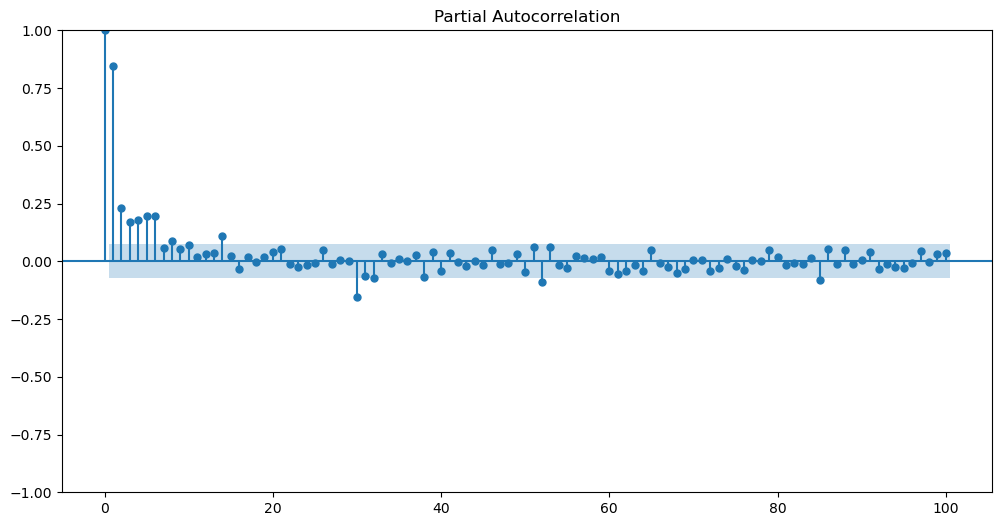

In [42]:
# PACF
fig, ax = plt.subplots(figsize = (12, 6))
plot_pacf(df_temp['y'], lags = 100, ax = ax)
plt.show()

# Model Assessment

In [ ]:
# Function that assesses the model and visualizes the train, test and forecast
def model_assessment(train, test, predictions, chart_title = None):
  # Set the chart size
  plt.figure(figsize = (10, 4))

  # Plot the train, test and forecast
  plt.plot(train, label = "Train")
  plt.plot(test, label = "Test")
  plt.plot(predictions, label = "Forecast")
  plt.title(chart_title)
  plt.legend()
  plt.show()

  # Calculate and print the RMSE, MAE, and MAPE
  rmse = root_mean_squared_error(test, predictions)
  mae = mean_absolute_error(test, predictions)
  mape = mean_absolute_percentage_error(test, predictions)
  print(f"RMSE: {rmse:.0f}")
  print(f"MAE: {mae:.0f}")
  print(f"MAPE: {100 * mape:.1f} %")

# Plot the future

In [ ]:
def plot_future(y, forecast, chart_title = None):
  # Plot the training data and forecast
  plt.figure(figsize = (10, 4))

  # Plot the train, test and forecast
  plt.plot(y, label = "Train")
  plt.plot(forecast, label = "Forecast")

  # Add a title and legend to the plot
  plt.title(chart_title)
  plt.legend()
  plt.show()
